In [ ]:
from bayes_opt import BayesianOptimization
import numpy as np

# Fixed cookie quality function
def bake_cookie(baking_time, temperature):
    perfect_time = 11
    perfect_temp = 360

    time_diff = abs(baking_time - perfect_time)/7
    temp_diff = abs(temperature - perfect_temp)/100
    
    score = 100 - ((baking_time - perfect_time)**2 + (temperature - perfect_temp)**2)
    score += np.random.normal(0, 5)
    
    if score < 30:
        return score, "Burnt! 🔥"
    elif score < 70:
        return score, "Okay 🍪"
    else:
        return score, "PERFECT! 🌟"


optimizer = BayesianOptimization(
    f=lambda baking_time, temperature: bake_cookie(baking_time, temperature)[0],  # Match parameter names
    pbounds={
        'baking_time': (8, 15),
        'temperature': (300, 400)
    },
    random_state=42
)

# Initial random tests
print("Testing random combinations:")
for _ in range(5):
    time = np.random.uniform(8, 15)
    temp = np.random.uniform(300, 400)
    score, result = bake_cookie(time, temp)
    print(f"{time:.1f} mins at {temp:.0f}°F → {result} ({score:.1f})")

# Smart optimization
print("\nSmart tests:")
optimizer.maximize(init_points=0, n_iter=5)

# Results
best = optimizer.max
score, result = bake_cookie(best['params']['baking_time'], best['params']['temperature'])
print(f"\nBest found: {best['params']['baking_time']:.1f} mins at {best['params']['temperature']:.0f}°F")
print(f"Result: {result} (Score: {score:.1f})")

Testing random combinations:
8.7 mins at 369°F → Burnt! 🔥 (16.4)
14.8 mins at 353°F → Okay 🍪 (37.4)
9.3 mins at 318°F → Burnt! 🔥 (-1667.6)
13.1 mins at 386°F → Burnt! 🔥 (-572.2)
14.0 mins at 385°F → Burnt! 🔥 (-535.8)

Smart tests:
|   iter    |  target   | baking... | temper... |
-------------------------------------------------
| 1         | -1131.805 | 10.621780 | 395.07143 |
| 2         | 79.770274 | 14.063233 | 364.38679 |
| 3         | 55.494562 | 14.980077 | 365.32528 |
| 4         | -617.9800 | 15.0      | 333.46746 |
| 5         | -3503.105 | 8.0       | 300.0     |
| 6         | -5.298971 | 15.0      | 350.59095 |

Best found: 14.1 mins at 364°F
Result: PERFECT! 🌟 (Score: 78.9)


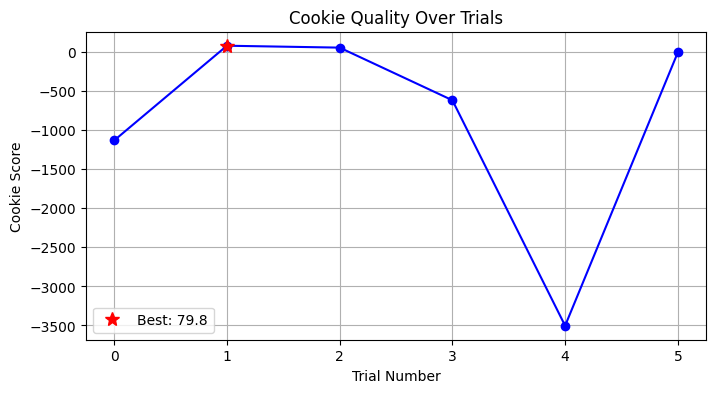

In [3]:
import matplotlib.pyplot as plt

# 1. Get the scores from all trials
scores = [res['target'] for res in optimizer.res]

plt.figure(figsize=(8, 4))
plt.plot(scores, 'bo-')  # Blue circles connected by lines


plt.xlabel("Trial Number")
plt.ylabel("Cookie Score")
plt.title("Cookie Quality Over Trials")


best_score = max(scores)
best_trial = scores.index(best_score)
plt.plot(best_trial, best_score, 'r*', markersize=10, label=f'Best: {best_score:.1f}')


plt.legend()
plt.grid(True)
plt.show()